# A04 — Fashion-MNIST
## Baseline CNN → Improved CNN → PyTorch → TensorFlow/Keras

Notebook này tiếp nối phần **MNIST** của Assignment 04, nhưng áp dụng trên dataset **Fashion-MNIST**.

Flow:

```text
Fashion-MNIST
│
├── Load dữ liệu CSV
├── EDA + preprocessing
│
├── PyTorch
│   ├── Baseline CNN
│   └── Improved CNN
│
├── TensorFlow / Keras
│   ├── Baseline CNN
│   └── Improved CNN
│
└── So sánh
    ├── Accuracy / Precision / Recall / F1
    ├── Loss
    ├── Parameters
    ├── Training time
    ├── Confusion matrix
    └── Prediction sai
```

### Vì sao notebook này không lặp lại toàn bộ NumPy From Scratch?

Phần **CNN From Scratch bằng NumPy** đã được làm đầy đủ ở notebook MNIST để chứng minh cách tự cài:
`Conv2D → ReLU → Pooling → Dense → Softmax → Backprop → Update weight`.

Với dataset thứ hai, mục tiêu chính là kiểm tra khả năng **tái sử dụng kiến trúc CNN** trên dữ liệu khác và so sánh `Baseline` với `Improved` bằng hai framework.

> Nếu giảng viên yêu cầu cả 3 dataset đều phải train NumPy Scratch, có thể bổ sung lại phần đó sau.

# 0. Thư viện cần thiết

Environment `train-model` của bạn nên có:

```bash
pip install numpy pandas matplotlib scikit-learn torch torchvision tensorflow jupyter ipykernel
```

# 1. Import và cấu hình

In [1]:
from pathlib import Path
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

NumPy : 2.3.3
Pandas: 3.0.3


# 2. Xác định đường dẫn

Cấu trúc project hiện tại:

```text
a04/
├── data/
│   └── fashion-mnist.csv/
│       ├── fashion-mnist_train.csv
│       └── fashion-mnist_test.csv
└── notebook/
    └── Fashion_Mnist/
        └── <notebook này>
```

Notebook tự tìm thư mục dataset và thư mục output.

**Yêu cầu của bạn:** mọi file output (`.pt`, `.keras`, `.csv`) sẽ được lưu **cùng folder với file notebook**, tức:

```text
a04/notebook/Fashion_Mnist/
```

In [ ]:
def find_project_paths():
    current = Path.cwd().resolve()

    search_bases = [current, *current.parents]

    data_dir = None
    notebook_dir = None

    for base in search_bases:
        candidate_data = base / "a04" / "data" / "fashion-mnist.csv"

        if (candidate_data / "fashion-mnist_train.csv").exists() and (
            candidate_data / "fashion-mnist_test.csv"
        ).exists():
            data_dir = candidate_data

            candidate_notebook = base / "a04" / "notebook" / "Fashion_Mnist"

            candidate_notebook.mkdir(
                parents=True,
                exist_ok=True,
            )

            notebook_dir = candidate_notebook
            break

        # Trường hợp cwd đã nằm trong a04/
        candidate_data = base / "data" / "fashion-mnist.csv"

        if (candidate_data / "fashion-mnist_train.csv").exists() and (
            candidate_data / "fashion-mnist_test.csv"
        ).exists():
            data_dir = candidate_data

            candidate_notebook = base / "notebook" / "Fashion_Mnist"

            candidate_notebook.mkdir(
                parents=True,
                exist_ok=True,
            )

            notebook_dir = candidate_notebook
            break

    if data_dir is None:
        raise FileNotFoundError(
            "Không tìm thấy fashion-mnist_train.csv và "
            "fashion-mnist_test.csv trong a04/data/fashion-mnist.csv/"
        )

    return data_dir, notebook_dir


DATA_DIR, OUTPUT_DIR = find_project_paths()

TRAIN_CSV = DATA_DIR / "fashion-mnist_train.csv"
TEST_CSV = DATA_DIR / "fashion-mnist_test.csv"

print("DATA_DIR  :", DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("TRAIN_CSV :", TRAIN_CSV)
print("TEST_CSV  :", TEST_CSV)

DATA_DIR  : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\data\fashion-mnist.csv
OUTPUT_DIR: C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\notebook\Fashion_Mnist
TRAIN_CSV : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\data\fashion-mnist.csv\fashion-mnist_train.csv
TEST_CSV  : C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\data\fashion-mnist.csv\fashion-mnist_test.csv


# 3. Load Fashion-MNIST

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

display(train_df.head())

Train shape: (60000, 785)
Test shape : (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3.1. Ý nghĩa dataset

Fashion-MNIST gồm ảnh thời trang grayscale `28 × 28`, tương tự MNIST về kích thước nhưng khó hơn vì các class có hình dạng gần nhau.

Mapping class:

| Label | Class |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

In [ ]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

LABEL_COL = "label" if "label" in train_df.columns else train_df.columns[0]

pixel_cols = [col for col in train_df.columns if col != LABEL_COL]

print("Label column :", LABEL_COL)
print("Pixel columns:", len(pixel_cols))
print("Classes      :", sorted(train_df[LABEL_COL].unique()))

assert len(pixel_cols) == 784
assert train_df[LABEL_COL].between(0, 9).all()
assert test_df[LABEL_COL].between(0, 9).all()

Label column : label
Pixel columns: 784
Classes      : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


# 4. EDA

## 4.1. Phân bố class

,label,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


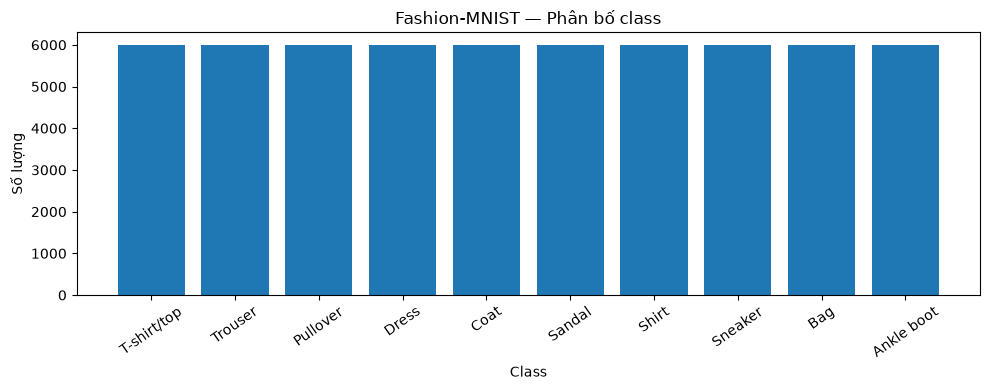

In [ ]:
class_counts = train_df[LABEL_COL].value_counts().sort_index()

distribution_df = pd.DataFrame(
    {
        "label": class_counts.index,
        "class_name": [CLASS_NAMES[i] for i in class_counts.index],
        "count": class_counts.values,
    }
)

display(distribution_df)

plt.figure(figsize=(10, 4))
plt.bar(
    distribution_df["class_name"],
    distribution_df["count"],
)
plt.xlabel("Class")
plt.ylabel("Số lượng")
plt.title("Fashion-MNIST — Phân bố class")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## 4.2. Hiển thị mẫu ảnh

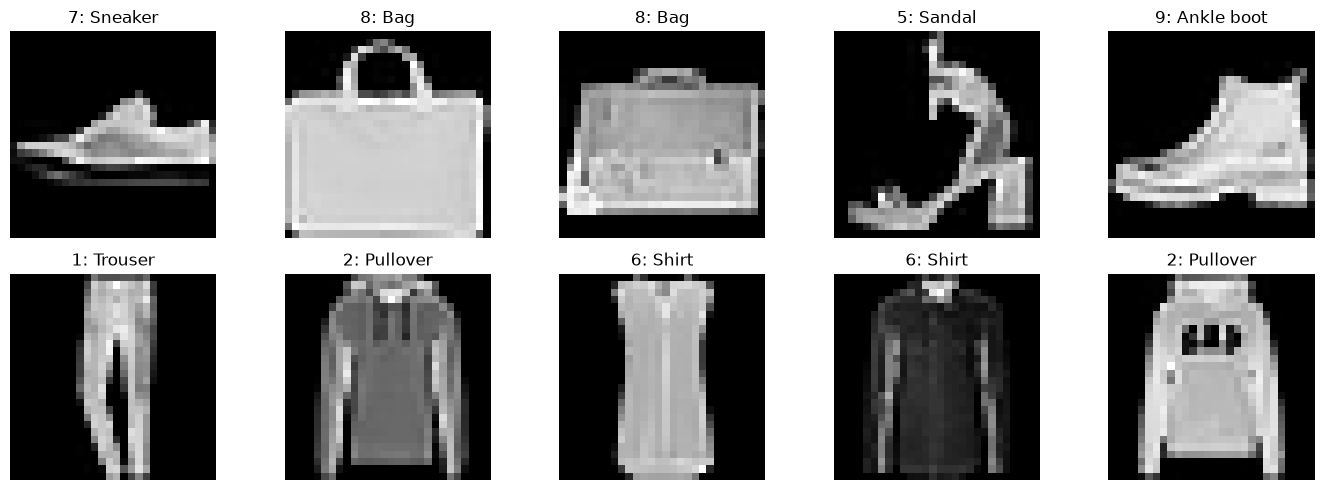

In [ ]:
def show_samples(df, n=10, random_state=SEED):
    sample_df = df.sample(
        n=n,
        random_state=random_state,
    )

    plt.figure(figsize=(14, 5))

    for i, (_, row) in enumerate(
        sample_df.iterrows(),
        start=1,
    ):
        image = row[pixel_cols].to_numpy(dtype=np.float32).reshape(28, 28)

        label = int(row[LABEL_COL])

        plt.subplot(2, 5, i)
        plt.imshow(image, cmap="gray")
        plt.title(f"{label}: {CLASS_NAMES[label]}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_samples(train_df)

# 5. Preprocessing

In [ ]:
X_full = train_df[pixel_cols].to_numpy(dtype=np.float32)

y_full = train_df[LABEL_COL].to_numpy(dtype=np.int64)

X_test = test_df[pixel_cols].to_numpy(dtype=np.float32)

y_test = test_df[LABEL_COL].to_numpy(dtype=np.int64)

# Normalize [0,255] -> [0,1]
X_full /= 255.0
X_test /= 255.0

# NCHW cho PyTorch:
# (N, C, H, W)
X_full = X_full.reshape(-1, 1, 28, 28)
X_test = X_test.reshape(-1, 1, 28, 28)

# Tách validation từ train
X_train, X_val, y_train, y_val = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=SEED,
    stratify=y_full,
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (48000, 1, 28, 28) (48000,)
Val  : (12000, 1, 28, 28) (12000,)
Test : (10000, 1, 28, 28) (10000,)


# PHẦN A — PYTORCH

Baseline:

```text
Input
→ Conv32 → ReLU → Pool
→ Conv64 → ReLU → Pool
→ Dense128
→ Output10
```

Improved:

```text
Input
→ Conv32 → BatchNorm → ReLU → Pool
→ Conv64 → BatchNorm → ReLU → Pool
→ Conv128 → BatchNorm → ReLU
→ Dense128 → Dropout
→ Output10
```

## 6. Import PyTorch và device

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)

PyTorch: 2.14.0+cpu
Device : cpu


## 6.1. Dataset / DataLoader

In [9]:
class FashionMNISTArrayDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(
            X,
            dtype=torch.float32,
        )
        self.y = torch.tensor(
            y,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 128

train_loader = DataLoader(
    FashionMNISTArrayDataset(
        X_train,
        y_train,
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    FashionMNISTArrayDataset(
        X_val,
        y_val,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    FashionMNISTArrayDataset(
        X_test,
        y_test,
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

images, labels = next(iter(train_loader))

print("Batch image:", images.shape)
print("Batch label:", labels.shape)

Batch image: torch.Size([128, 1, 28, 28])
Batch label: torch.Size([128])


# 7. PyTorch Baseline CNN

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                64 * 7 * 7,
                128,
            ),
            nn.ReLU(),
            nn.Linear(
                128,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 8. PyTorch Improved CNN

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1,
                32,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1,
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(
                128 * 7 * 7,
                128,
            ),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(
                128,
                10,
            ),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## 8.1. Shape và số parameter

In [ ]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def inspect_shapes(model, sample):
    x = sample

    print("Input:", tuple(x.shape))

    for i, layer in enumerate(model.features):
        x = layer(x)
        print(f"features[{i:02d}] {layer.__class__.__name__:15s} -> {tuple(x.shape)}")

    x = model.classifier(x)

    print("Output:", tuple(x.shape))


baseline_model = BaselineCNN().to(DEVICE)
improved_model = ImprovedCNN().to(DEVICE)

sample, _ = next(iter(train_loader))
sample = sample[:4].to(DEVICE)

print("BASELINE")
inspect_shapes(
    baseline_model,
    sample,
)
print(
    "Parameters:",
    f"{count_params(baseline_model):,}",
)

print("\nIMPROVED")
inspect_shapes(
    improved_model,
    sample,
)
print(
    "Parameters:",
    f"{count_params(improved_model):,}",
)

BASELINE
Input: (4, 1, 28, 28)
features[00] Conv2d          -> (4, 32, 28, 28)
features[01] ReLU            -> (4, 32, 28, 28)
features[02] MaxPool2d       -> (4, 32, 14, 14)
features[03] Conv2d          -> (4, 64, 14, 14)
features[04] ReLU            -> (4, 64, 14, 14)
features[05] MaxPool2d       -> (4, 64, 7, 7)
Output: (4, 10)
Parameters: 421,642

IMPROVED
Input: (4, 1, 28, 28)
features[00] Conv2d          -> (4, 32, 28, 28)
features[01] BatchNorm2d     -> (4, 32, 28, 28)
features[02] ReLU            -> (4, 32, 28, 28)
features[03] MaxPool2d       -> (4, 32, 14, 14)
features[04] Conv2d          -> (4, 64, 14, 14)
features[05] BatchNorm2d     -> (4, 64, 14, 14)
features[06] ReLU            -> (4, 64, 14, 14)
features[07] MaxPool2d       -> (4, 64, 7, 7)
features[08] Conv2d          -> (4, 128, 7, 7)
features[09] BatchNorm2d     -> (4, 128, 7, 7)
features[10] ReLU            -> (4, 128, 7, 7)
Output: (4, 10)
Parameters: 897,354


# 9. Training / Evaluation PyTorch

In [ ]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images)
        loss = criterion(
            logits,
            labels,
        )

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        pred = logits.argmax(dim=1)

        correct += (pred == labels).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


@torch.no_grad()
def evaluate_torch(
    model,
    loader,
    criterion,
):
    model.eval()

    total_loss = 0.0

    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)

        loss = criterion(
            logits,
            labels,
        )

        pred = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": total_loss / len(loader.dataset),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": y_true,
        "y_pred": y_pred,
    }


def fit_torch(
    model,
    epochs=5,
    learning_rate=1e-3,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    start = time.perf_counter()

    for epoch in range(
        1,
        epochs + 1,
    ):
        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_result = evaluate_torch(
            model,
            val_loader,
            criterion,
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["val_loss"].append(val_result["loss"])
        history["val_accuracy"].append(val_result["accuracy"])

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"val_loss={val_result['loss']:.4f} | "
            f"val_acc={val_result['accuracy']:.4f}"
        )

    elapsed = time.perf_counter() - start

    return history, elapsed

## 9.1. Hàm vẽ learning curve

In [14]:
def plot_history(history, title):
    epochs = range(
        1,
        len(history["train_loss"]) + 1,
    )

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        history["train_loss"],
        marker="o",
        label="Train Loss",
    )
    plt.plot(
        epochs,
        history["val_loss"],
        marker="o",
        label="Val Loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Train Accuracy",
    )
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Val Accuracy",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.show()

# 10. Train PyTorch Baseline

Epoch 01/5 | train_loss=0.5642 | train_acc=0.7978 | val_loss=0.3671 | val_acc=0.8678
Epoch 02/5 | train_loss=0.3473 | train_acc=0.8754 | val_loss=0.3406 | val_acc=0.8755
Epoch 03/5 | train_loss=0.2984 | train_acc=0.8932 | val_loss=0.3082 | val_acc=0.8878
Epoch 04/5 | train_loss=0.2685 | train_acc=0.9036 | val_loss=0.2755 | val_acc=0.9003
Epoch 05/5 | train_loss=0.2425 | train_acc=0.9123 | val_loss=0.2542 | val_acc=0.9077


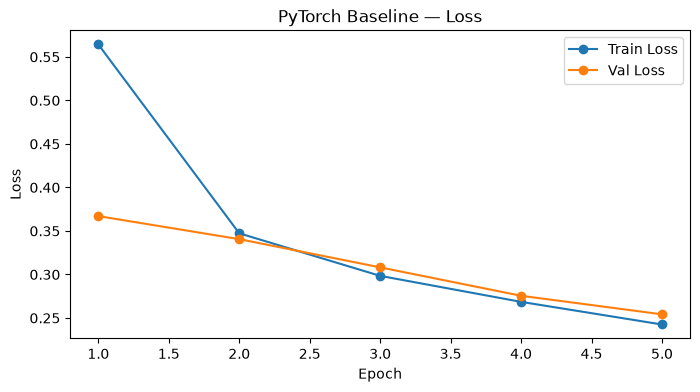

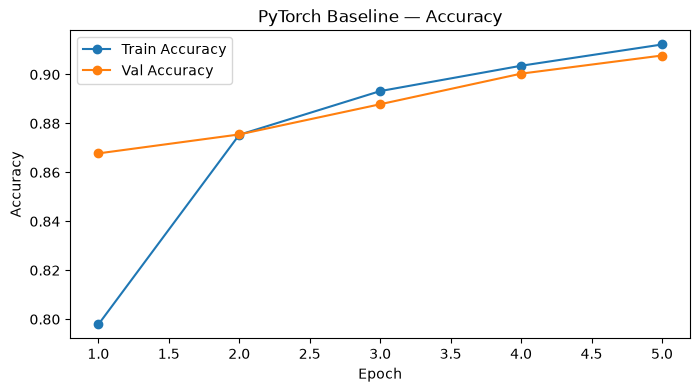

In [ ]:
EPOCHS = 5
LEARNING_RATE = 1e-3

torch.manual_seed(SEED)

baseline_model = BaselineCNN().to(DEVICE)

baseline_history, baseline_time = fit_torch(
    baseline_model,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
)

plot_history(
    baseline_history,
    "PyTorch Baseline",
)

# 11. Train PyTorch Improved

Epoch 01/5 | train_loss=0.4256 | train_acc=0.8473 | val_loss=0.2791 | val_acc=0.9012
Epoch 02/5 | train_loss=0.2749 | train_acc=0.8988 | val_loss=0.2529 | val_acc=0.9062
Epoch 03/5 | train_loss=0.2355 | train_acc=0.9137 | val_loss=0.2308 | val_acc=0.9147
Epoch 04/5 | train_loss=0.2049 | train_acc=0.9249 | val_loss=0.2200 | val_acc=0.9194
Epoch 05/5 | train_loss=0.1829 | train_acc=0.9332 | val_loss=0.2285 | val_acc=0.9220


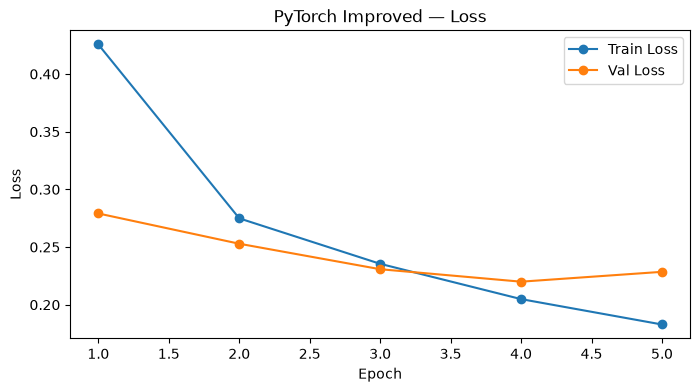

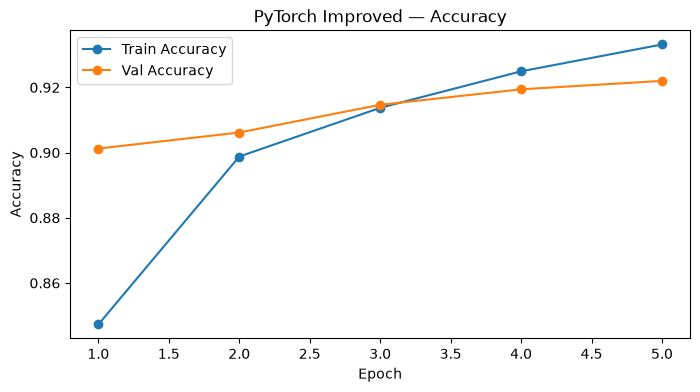

In [ ]:
torch.manual_seed(SEED)

improved_model = ImprovedCNN().to(DEVICE)

improved_history, improved_time = fit_torch(
    improved_model,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
)

plot_history(
    improved_history,
    "PyTorch Improved",
)

# 12. Test PyTorch

In [ ]:
criterion = nn.CrossEntropyLoss()

baseline_test = evaluate_torch(
    baseline_model,
    test_loader,
    criterion,
)

improved_test = evaluate_torch(
    improved_model,
    test_loader,
    criterion,
)

torch_results = pd.DataFrame(
    [
        {
            "Implementation": "PyTorch",
            "Model": "Baseline CNN",
            "Loss": baseline_test["loss"],
            "Accuracy": baseline_test["accuracy"],
            "Precision": baseline_test["precision"],
            "Recall": baseline_test["recall"],
            "F1": baseline_test["f1"],
            "Parameters": count_params(baseline_model),
            "Train Time (s)": baseline_time,
        },
        {
            "Implementation": "PyTorch",
            "Model": "Improved CNN",
            "Loss": improved_test["loss"],
            "Accuracy": improved_test["accuracy"],
            "Precision": improved_test["precision"],
            "Recall": improved_test["recall"],
            "F1": improved_test["f1"],
            "Parameters": count_params(improved_model),
            "Train Time (s)": improved_time,
        },
    ]
)

display(torch_results)

,Implementation,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,PyTorch,Baseline CNN,0.240790,0.9116,0.911809,0.9116,0.911157,421642,71.678811
1,PyTorch,Improved CNN,0.213664,0.9254,0.925723,0.9254,0.924816,897354,112.194933


# PHẦN B — TENSORFLOW / KERAS

TensorFlow dùng format:

```text
NHWC = (batch, height, width, channels)
```

nên cần đổi từ NCHW sang NHWC.

# 13. Import TensorFlow

In [18]:
import tensorflow as tf

tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print(
    "GPU devices:",
    tf.config.list_physical_devices("GPU"),
)

TensorFlow: 2.21.0
GPU devices: []


## 13.1. NCHW → NHWC

In [19]:
X_train_tf = np.transpose(
    X_train,
    (0, 2, 3, 1),
)

X_val_tf = np.transpose(
    X_val,
    (0, 2, 3, 1),
)

X_test_tf = np.transpose(
    X_test,
    (0, 2, 3, 1),
)

print("Train:", X_train_tf.shape)
print("Val  :", X_val_tf.shape)
print("Test :", X_test_tf.shape)

Train: (48000, 28, 28, 1)
Val  : (12000, 28, 28, 1)
Test : (10000, 28, 28, 1)


# 14. TensorFlow Baseline

In [ ]:
def build_tf_baseline():
    inputs = tf.keras.Input(shape=(28, 28, 1))

    x = tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        activation="relu",
    )(inputs)

    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)

    x = tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        activation="relu",
    )(x)

    x = tf.keras.layers.MaxPool2D(pool_size=2)(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(x)

    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="FashionMNIST_Baseline",
    )


tf_baseline = build_tf_baseline()

tf_baseline.summary()

Model: "FashionMNIST_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

# 15. TensorFlow Improved

In [ ]:
def build_tf_improved():
    inputs = tf.keras.Input(shape=(28, 28, 1))

    x = tf.keras.layers.Conv2D(
        32,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(inputs)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    x = tf.keras.layers.Conv2D(
        64,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.MaxPool2D(2)(x)

    x = tf.keras.layers.Conv2D(
        128,
        kernel_size=3,
        padding="same",
        use_bias=False,
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.ReLU()(x)

    x = tf.keras.layers.Flatten()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu",
    )(x)

    x = tf.keras.layers.Dropout(0.3)(x)

    outputs = tf.keras.layers.Dense(10)(x)

    return tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="FashionMNIST_Improved",
    )


tf_improved = build_tf_improved()

tf_improved.summary()

Model: "FashionMNIST_Improved"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897,578 (3.42 MB)

 Trainable params: 897,130 (3.42 MB)

 Non-trainable params: 448 (1.75 KB)

# 16. Train / Evaluate TensorFlow

In [ ]:
def compile_tf(model):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )


def fit_tf(model, epochs=5):
    compile_tf(model)

    start = time.perf_counter()

    history = model.fit(
        X_train_tf,
        y_train,
        validation_data=(
            X_val_tf,
            y_val,
        ),
        epochs=epochs,
        batch_size=128,
        verbose=1,
    )

    elapsed = time.perf_counter() - start

    return history, elapsed


def evaluate_tf(model):
    test_loss, _ = model.evaluate(
        X_test_tf,
        y_test,
        batch_size=128,
        verbose=0,
    )

    logits = model.predict(
        X_test_tf,
        batch_size=128,
        verbose=0,
    )

    pred = logits.argmax(axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        pred,
        average="macro",
        zero_division=0,
    )

    return {
        "loss": float(test_loss),
        "accuracy": accuracy_score(
            y_test,
            pred,
        ),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "y_true": y_test.copy(),
        "y_pred": pred,
    }

## 16.1. Hàm vẽ history TensorFlow

In [23]:
def plot_tf_history(history, title):
    h = history.history
    epochs = range(
        1,
        len(h["loss"]) + 1,
    )

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        h["loss"],
        marker="o",
        label="Train Loss",
    )
    plt.plot(
        epochs,
        h["val_loss"],
        marker="o",
        label="Val Loss",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} — Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(
        epochs,
        h["accuracy"],
        marker="o",
        label="Train Accuracy",
    )
    plt.plot(
        epochs,
        h["val_accuracy"],
        marker="o",
        label="Val Accuracy",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} — Accuracy")
    plt.legend()
    plt.show()

# 17. Train TensorFlow Baseline

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.8122 - loss: 0.5247 - val_accuracy: 0.8695 - val_loss: 0.3585
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8815 - loss: 0.3321 - val_accuracy: 0.8724 - val_loss: 0.3448
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.8957 - loss: 0.2896 - val_accuracy: 0.8758 - val_loss: 0.3359
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9072 - loss: 0.2597 - val_accuracy: 0.8830 - val_loss: 0.3171
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9150 - loss: 0.2363 - val_accuracy: 0.8932 - val_loss: 0.2958


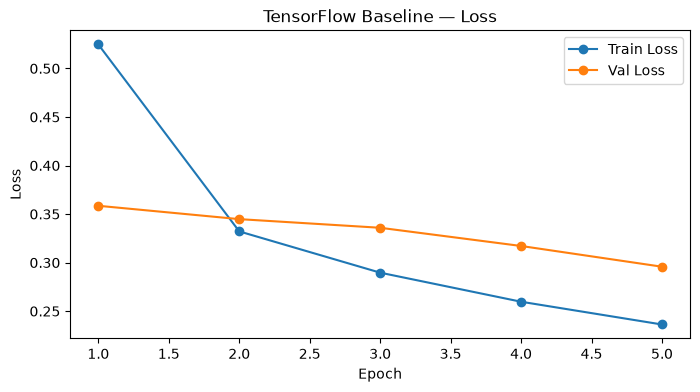

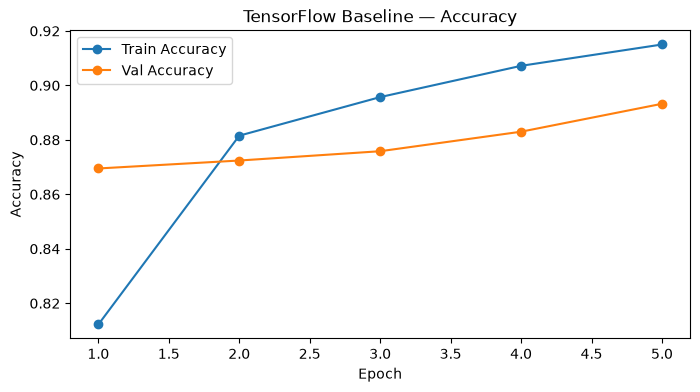

In [24]:
tf.random.set_seed(SEED)

tf_baseline = build_tf_baseline()

tf_baseline_history, tf_baseline_time = fit_tf(
    tf_baseline,
    epochs=5,
)

plot_tf_history(
    tf_baseline_history,
    "TensorFlow Baseline",
)

# 18. Train TensorFlow Improved

Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - accuracy: 0.8321 - loss: 0.4787 - val_accuracy: 0.6708 - val_loss: 0.9193
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.8876 - loss: 0.3141 - val_accuracy: 0.8967 - val_loss: 0.2835
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9039 - loss: 0.2658 - val_accuracy: 0.8897 - val_loss: 0.2918
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9154 - loss: 0.2323 - val_accuracy: 0.9081 - val_loss: 0.2524
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.9235 - loss: 0.2078 - val_accuracy: 0.9053 - val_loss: 0.2647


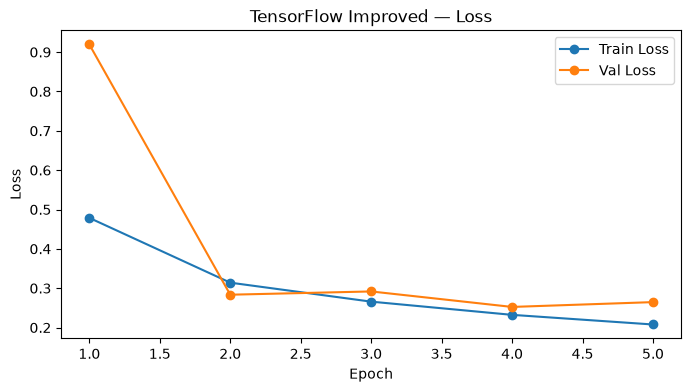

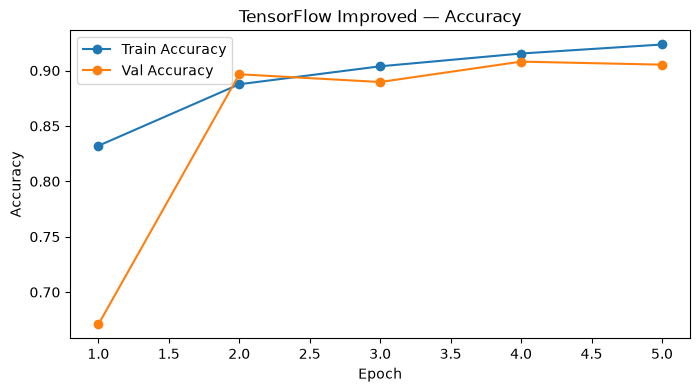

In [25]:
tf.random.set_seed(SEED)

tf_improved = build_tf_improved()

tf_improved_history, tf_improved_time = fit_tf(
    tf_improved,
    epochs=5,
)

plot_tf_history(
    tf_improved_history,
    "TensorFlow Improved",
)

# 19. Test TensorFlow

In [ ]:
tf_baseline_test = evaluate_tf(tf_baseline)

tf_improved_test = evaluate_tf(tf_improved)

tf_results = pd.DataFrame(
    [
        {
            "Implementation": "TensorFlow",
            "Model": "Baseline CNN",
            "Loss": tf_baseline_test["loss"],
            "Accuracy": tf_baseline_test["accuracy"],
            "Precision": tf_baseline_test["precision"],
            "Recall": tf_baseline_test["recall"],
            "F1": tf_baseline_test["f1"],
            "Parameters": tf_baseline.count_params(),
            "Train Time (s)": tf_baseline_time,
        },
        {
            "Implementation": "TensorFlow",
            "Model": "Improved CNN",
            "Loss": tf_improved_test["loss"],
            "Accuracy": tf_improved_test["accuracy"],
            "Precision": tf_improved_test["precision"],
            "Recall": tf_improved_test["recall"],
            "F1": tf_improved_test["f1"],
            "Parameters": tf_improved.count_params(),
            "Train Time (s)": tf_improved_time,
        },
    ]
)

display(tf_results)

,Implementation,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,TensorFlow,Baseline CNN,0.294991,0.8929,0.905750,0.8929,0.895222,421642,31.211607
1,TensorFlow,Improved CNN,0.250187,0.9082,0.914424,0.9082,0.909590,897578,81.597875


# PHẦN C — SO SÁNH VÀ PHÂN TÍCH

# 20. Tổng hợp kết quả

In [ ]:
all_results = pd.concat(
    [
        torch_results,
        tf_results,
    ],
    ignore_index=True,
)

display(
    all_results.style.format(
        {
            "Loss": "{:.4f}",
            "Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "Parameters": "{:,.0f}",
            "Train Time (s)": "{:.2f}",
        }
    )
)

,Implementation,Model,Loss,Accuracy,Precision,Recall,F1,Parameters,Train Time (s)
0,PyTorch,Baseline CNN,0.2408,0.9116,0.9118,0.9116,0.9112,"421,642",71.68
1,PyTorch,Improved CNN,0.2137,0.9254,0.9257,0.9254,0.9248,"897,354",112.19
2,TensorFlow,Baseline CNN,0.2950,0.8929,0.9058,0.8929,0.8952,"421,642",31.21
3,TensorFlow,Improved CNN,0.2502,0.9082,0.9144,0.9082,0.9096,"897,578",81.60


# 21. Biểu đồ Accuracy

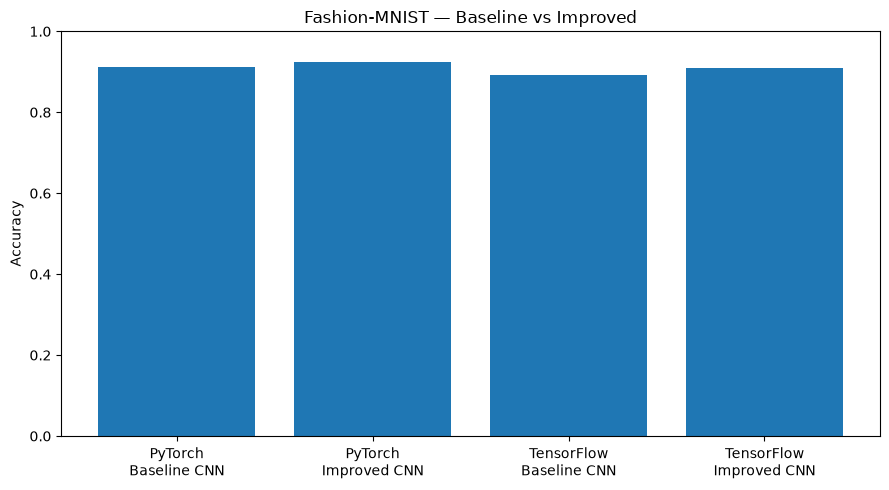

In [ ]:
labels = all_results["Implementation"] + "\n" + all_results["Model"]

plt.figure(figsize=(9, 5))

plt.bar(
    labels,
    all_results["Accuracy"],
)

plt.ylabel("Accuracy")
plt.title("Fashion-MNIST — Baseline vs Improved")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 22. Confusion Matrix — PyTorch Improved

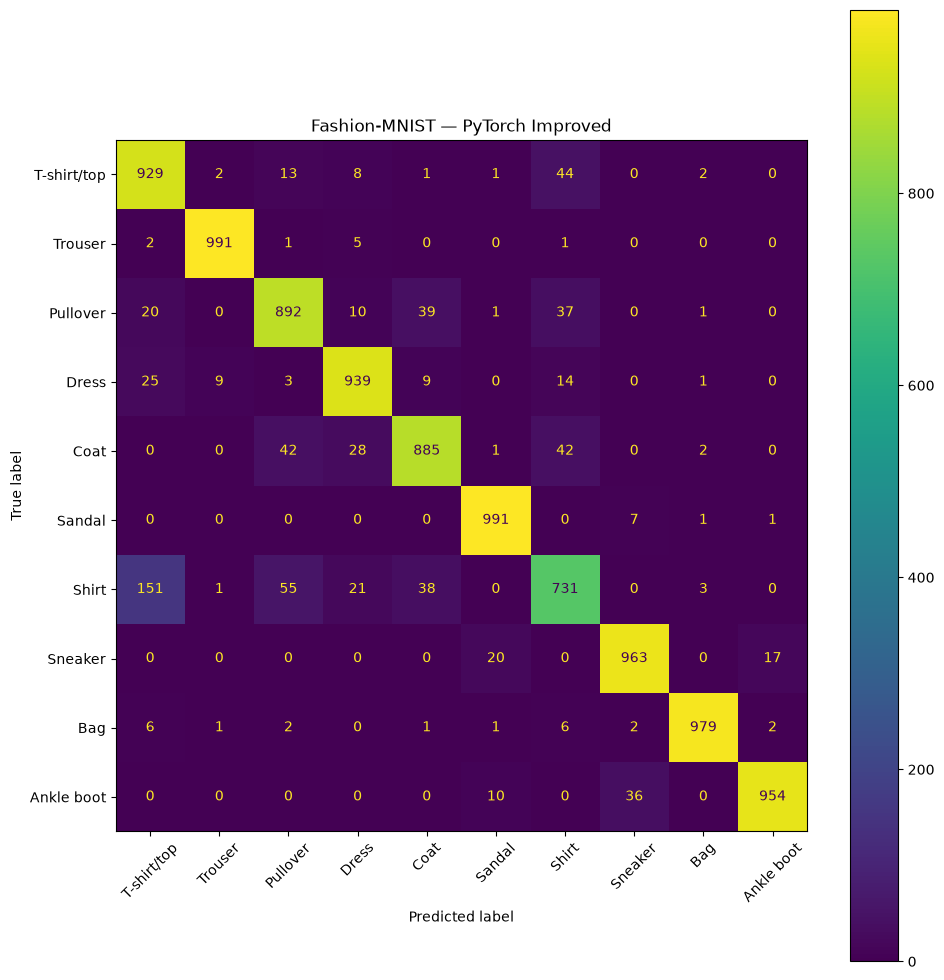

In [ ]:
cm = confusion_matrix(
    improved_test["y_true"],
    improved_test["y_pred"],
)

fig, ax = plt.subplots(figsize=(10, 10))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES,
).plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45,
)

plt.title("Fashion-MNIST — PyTorch Improved")
plt.tight_layout()
plt.show()

# 23. Classification Report

In [30]:
print(
    classification_report(
        improved_test["y_true"],
        improved_test["y_pred"],
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

 T-shirt/top     0.8199    0.9290    0.8711      1000
     Trouser     0.9871    0.9910    0.9890      1000
    Pullover     0.8849    0.8920    0.8884      1000
       Dress     0.9288    0.9390    0.9339      1000
        Coat     0.9096    0.8850    0.8971      1000
      Sandal     0.9668    0.9910    0.9788      1000
       Shirt     0.8354    0.7310    0.7797      1000
     Sneaker     0.9554    0.9630    0.9592      1000
         Bag     0.9899    0.9790    0.9844      1000
  Ankle boot     0.9795    0.9540    0.9666      1000

    accuracy                         0.9254     10000
   macro avg     0.9257    0.9254    0.9248     10000
weighted avg     0.9257    0.9254    0.9248     10000



# 24. Xem các prediction sai

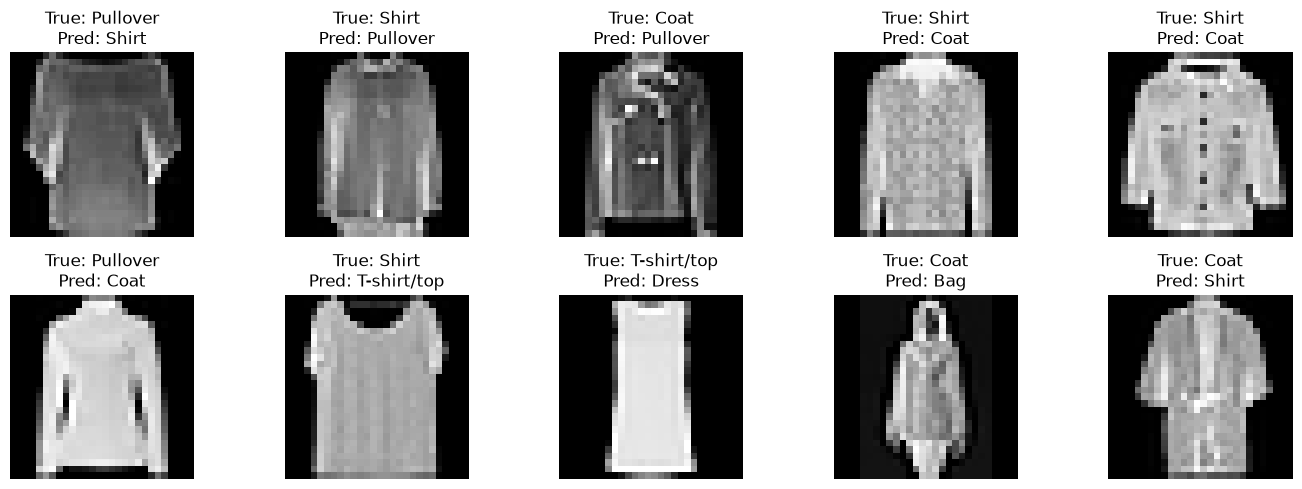

In [ ]:
@torch.no_grad()
def collect_mistakes(
    model,
    loader,
    max_items=10,
):
    model.eval()

    mistakes = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images)
        pred = logits.argmax(dim=1)

        wrong = pred != labels

        for image, true_label, pred_label in zip(
            images[wrong].cpu(),
            labels[wrong].cpu(),
            pred[wrong].cpu(),
        ):
            mistakes.append(
                (
                    image.squeeze(0).numpy(),
                    int(true_label),
                    int(pred_label),
                )
            )

            if len(mistakes) >= max_items:
                return mistakes

    return mistakes


mistakes = collect_mistakes(
    improved_model,
    test_loader,
    max_items=10,
)

plt.figure(figsize=(14, 5))

for i, (
    image,
    true_label,
    pred_label,
) in enumerate(
    mistakes,
    start=1,
):
    plt.subplot(2, 5, i)

    plt.imshow(
        image,
        cmap="gray",
    )

    plt.title(f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]}")

    plt.axis("off")

plt.tight_layout()
plt.show()

# 25. Phân tích lỗi theo từng class

Fashion-MNIST thường có các cặp khó phân biệt, ví dụ:

```text
T-shirt/top ↔ Shirt
Pullover ↔ Coat
Shirt ↔ Coat
Sandal ↔ Sneaker / Ankle boot
```

Cell dưới tính accuracy riêng từng class để xác định class nào khó nhất.

In [ ]:
def per_class_accuracy(
    y_true,
    y_pred,
):
    rows = []

    for label, class_name in enumerate(CLASS_NAMES):
        mask = y_true == label

        total = mask.sum()

        correct = (y_pred[mask] == label).sum()

        rows.append(
            {
                "Label": label,
                "Class": class_name,
                "Samples": int(total),
                "Correct": int(correct),
                "Accuracy": (correct / total if total > 0 else np.nan),
            }
        )

    return pd.DataFrame(rows)


class_accuracy_df = per_class_accuracy(
    improved_test["y_true"],
    improved_test["y_pred"],
)

display(class_accuracy_df.style.format({"Accuracy": "{:.4f}"}))

,Label,Class,Samples,Correct,Accuracy
0,0,T-shirt/top,1000,929,0.9290
1,1,Trouser,1000,991,0.9910
2,2,Pullover,1000,892,0.8920
3,3,Dress,1000,939,0.9390
4,4,Coat,1000,885,0.8850
5,5,Sandal,1000,991,0.9910
6,6,Shirt,1000,731,0.7310
7,7,Sneaker,1000,963,0.9630
8,8,Bag,1000,979,0.9790
9,9,Ankle boot,1000,954,0.9540


# 26. Lưu output CÙNG FOLDER VỚI NOTEBOOK

Theo yêu cầu, không tạo `../outputs/`.

Output sẽ nằm tại:

```text
a04/notebook/Fashion_Mnist/
├── A04_Fashion_MNIST_CNN.ipynb
├── fashion_mnist_torch_baseline.pt
├── fashion_mnist_torch_improved.pt
├── fashion_mnist_tf_baseline.keras
├── fashion_mnist_tf_improved.keras
├── fashion_mnist_results.csv
└── fashion_mnist_per_class_accuracy.csv
```

In [ ]:
# PyTorch model weights
torch.save(
    baseline_model.state_dict(),
    OUTPUT_DIR / "fashion_mnist_torch_baseline.pt",
)

torch.save(
    improved_model.state_dict(),
    OUTPUT_DIR / "fashion_mnist_torch_improved.pt",
)

# TensorFlow models
tf_baseline.save(OUTPUT_DIR / "fashion_mnist_tf_baseline.keras")

tf_improved.save(OUTPUT_DIR / "fashion_mnist_tf_improved.keras")

# Metrics
all_results.to_csv(
    OUTPUT_DIR / "fashion_mnist_results.csv",
    index=False,
)

class_accuracy_df.to_csv(
    OUTPUT_DIR / "fashion_mnist_per_class_accuracy.csv",
    index=False,
)

print("Đã lưu toàn bộ output tại:")
print(OUTPUT_DIR.resolve())

Đã lưu toàn bộ output tại:
C:\Users\datng\Desktop\GIÁO TRÌNH\NĂM 4 - KÌ 1\PTCHTTH - Phát Triển Các Hệ Thống Thông Minh\test\a04\notebook\Fashion_Mnist


# 27. Gợi ý nhận xét cho báo cáo A04

Sau khi chạy xong, **không viết trước kết luận rằng Improved chắc chắn tốt hơn**.

Hãy dựa trên bảng kết quả thực tế.

Có thể nhận xét theo form:

### Dataset

- Fashion-MNIST gồm ảnh grayscale `28×28`.
- Có 10 class quần áo/thời trang.
- Bài toán khó hơn MNIST chữ số vì một số class có hình dạng gần nhau.

### Baseline

Baseline cung cấp mốc so sánh với kiến trúc CNN đơn giản:

```text
2 convolution blocks
→ fully-connected classifier
```

### Improved

Improved bổ sung:

```text
Batch Normalization
+ convolution block sâu hơn
+ Dropout
```

### So sánh

So sánh ít nhất:

- Accuracy
- Precision
- Recall
- F1
- Loss
- Parameters
- Training time
- Confusion matrix

### Phân tích lỗi

Không chỉ nhìn accuracy tổng.

Cần xem:

- class nào khó;
- class nào hay nhầm lẫn với nhau;
- model Improved có giảm lỗi tại các class khó hay không.

---

# Flow phần Fashion-MNIST trong Assignment 04

```text
Fashion-MNIST CSV
       │
       ▼
Load + EDA
       │
       ▼
Preprocessing
       │
       ├─────────────────────┐
       ▼                     ▼
    PyTorch              TensorFlow
       │                     │
   Baseline               Baseline
       │                     │
   Improved               Improved
       │                     │
       └──────────┬──────────┘
                  ▼
              Evaluation
                  │
        Accuracy / F1 / Loss
                  │
        Confusion Matrix
                  │
          Error Analysis
                  │
              Conclusion
```